# 06: Concept Intervention (Stage 5)

Simulates a dermatologist correcting individual concept predictions and measures the rescue rate, stratified by Fitzpatrick bucket.

In [1]:
import os, sys, yaml, logging
from pathlib import Path
PROJECT_ROOT = Path(os.getcwd())
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

import numpy as np, pandas as pd
from src.models.concept_predictor import load_concept_bundle, CONCEPT_IDS
from src.models.cbm_classifier import CBMLogisticRegression
from src.evaluation.intervention import simulate_intervention
from src.visualization.plots import plot_intervention_rescue
from src.utils import seed_everything

logging.basicConfig(level=logging.INFO)
cfg = yaml.safe_load((PROJECT_ROOT / 'config.yaml').read_text())
paths = cfg['paths']
seed_everything(cfg.get('seed', 42))
cv_dir = PROJECT_ROOT / paths['concept_vectors_dir']
figs_dir = PROJECT_ROOT / paths['figures_dir']
tables_dir = PROJECT_ROOT / paths['tables_dir']

In [ ]:
# Use the Derm7pt test set (has concept GT) pooled with Fitzpatrick buckets from the DDI/Fitz17k sets. 
bundle = load_concept_bundle(cv_dir / 'concepts_derm7pt.npz')
fb = bundle.get('fitzpatrick_bucket')
if fb is None or pd.Series(fb).isna().all():
    # Derm7pt lacks FST labels; fall back to `overall` bucket
    fb = np.array(['overall'] * len(bundle['diagnosis']), dtype=object)

In [3]:
cbm = CBMLogisticRegression.load(PROJECT_ROOT / paths['checkpoints_dir'] / 'cbm_lr.joblib')

buckets = tuple(sorted({b for b in fb if b}))
res = simulate_intervention(
    cbm,
    concept_scores=bundle['concepts'],
    concept_labels=bundle['concept_labels'],
    diagnosis_true=bundle['diagnosis'],
    fitzpatrick_bucket=fb,
    concept_names=CONCEPT_IDS,
    buckets=buckets,
    max_k=cfg['intervention']['max_concepts_to_correct'],
)

print('Single-concept rescue rate:')
print(res.per_concept_rescue_rate)
print('\nMisclassified samples per bucket:')
print(res.per_concept_sample_counts)
print('\nTop-k rescue:')
print(res.top_k_rescue)

Single-concept rescue rate:
                  overall  overall_n_misclassified
pigment_network  0.173010                      289
dots_globules    0.013841                      289
blue_white_veil  0.653979                      289
streaks          0.000000                      289
regression       0.044983                      289
vascular         0.557093                      289
asymmetry        0.000000                      289
border           0.000000                      289
color_var        0.000000                      289

Misclassified samples per bucket:
         n_misclassified
overall              289

Top-k rescue:
         n_misclassified  rescue_rate@k=1  rescue_rate@k=2  rescue_rate@k=3
bucket                                                                     
overall              289         0.858131         0.865052         0.865052


/Users/deepesh/Documents/Claude/Projects/AIH Final/vlm-cbm-derm-fairness/src/visualization/plots.py:166: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, fontsize=8)


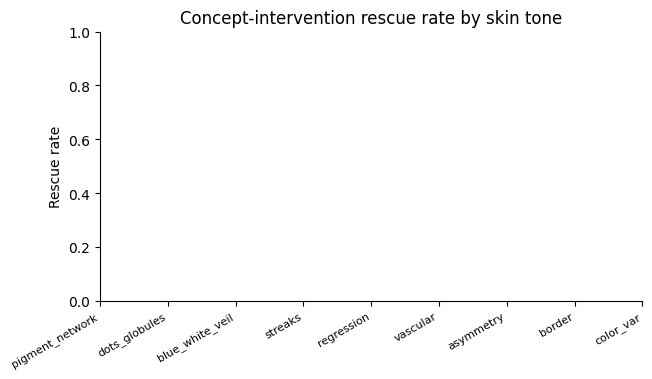

In [4]:
# Figure 5
plot_intervention_rescue(res.per_concept_rescue_rate, out_dir=figs_dir)

# CSV export
tables_dir.mkdir(parents=True, exist_ok=True)
res.per_concept_rescue_rate.to_csv(tables_dir / 'intervention_per_concept.csv')
res.top_k_rescue.to_csv(tables_dir / 'intervention_topk.csv')